# 02 — EDA de intensidades: endurecimiento de haz y desajuste de histograma
**Proyecto Integrador Corte 2 — PENGWIN**

El EDA de fragmentos (notebook 01) analiza las **máscaras**. Este analiza las **imágenes**: qué tan distintas son las intensidades (HU) entre casos y cuántos casos están contaminados por metal. De aquí debe salir, justificada con datos, la decisión de preprocesamiento que alimentará al modelo.

**Dos fenómenos a caracterizar:**

1. **Endurecimiento de haz (*beam hardening*) por metal.** Tornillos, placas y fijadores atenúan tanto el haz que el escáner reconstruye mal los alrededores: rayas brillantes y oscuras que salen del implante y alteran los HU del hueso vecino. Un vóxel > 3000 HU no es tejido: es metal.
2. **Desajuste de histograma entre casos.** Los 100 CT vienen de escáneres y protocolos distintos (kVp, kernel de reconstrucción, contraste, campo de visión), así que el mismo hueso puede caer en rangos de HU distintos según el paciente. Una normalización fija no le sirve igual a todos.

**Flujo de trabajo:** la lógica se escribe en una celda con `%%writefile`, que genera `src/eda_intensidades.py`. El notebook importa ese módulo, lo ejecuta y grafica. Así el entregable final queda en `.py` y el notebook es solo el seguimiento.

> Uso exclusivamente académico. No es un dispositivo médico.

In [1]:
# --- Setup: ubicarse en la raíz del repo (los scripts usan rutas relativas data/ y outputs/) ---
import os, sys
from pathlib import Path
if Path.cwd().name == "notebooks":
    os.chdir("..")
if "src" not in sys.path:
    sys.path.insert(0, "src")
assert Path("data/raw").exists(), "No encuentro data/raw: descarga PENGWIN de Zenodo y descomprímelo ahí (ver README)."

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import SimpleITK as sitk
from IPython.display import Image, display

SEED = 42
np.random.seed(SEED)
print("Raíz del repo:", Path.cwd())

Raíz del repo: /Users/mariavalencia/Downloads/Proyecto 2 analitica de datos


## 1. Módulo de análisis (`%%writefile` → `src/eda_intensidades.py`)
Al ejecutar esta celda **no se corre el código**: se guarda como archivo `.py`. Si se cambia algo aquí, hay que volver a ejecutarla para regenerar el script.

Por cada caso calcula: vóxeles y volumen de metal, cortes afectados, fracción de padding, histograma del cuerpo (HU > -500) y del **hueso según la máscara**, con percentiles, media y desviación. Los percentiles se sacan del histograma (resolución 10 HU) para no ordenar ~100 millones de vóxeles por caso.

In [2]:
%%writefile src/eda_intensidades.py
"""
eda_intensidades.py
--------------------
EDA de INTENSIDADES (HU) del dataset PENGWIN. Complementa a eda_fragments.py
(que analiza las máscaras). Caracteriza dos fenómenos del CT crudo:

1. Metal / endurecimiento de haz: vóxeles > HU_METAL por caso, volumen en mm3,
   número de cortes afectados y corte con más metal.
2. Desajuste de histograma entre casos: histograma de HU del cuerpo y del hueso
   (usando la máscara), percentiles, media y desviación por caso.

Genera:
- data/eda_intensidades_detalle.csv        (una fila por caso)
- data/eda_intensidades_histogramas.npz    (histogramas normalizados por caso)

ARCHIVO GENERADO desde notebooks/02_eda_intensidades.ipynb con %%writefile.
Para cambiarlo, editar la celda del notebook y volver a ejecutarla.

Uso (desde la raíz del repo):
    python src/eda_intensidades.py
"""

from pathlib import Path
import numpy as np
import pandas as pd
import SimpleITK as sitk
from tqdm import tqdm

# ---------------------------------------------------------------------------
# CONFIGURACIÓN
# ---------------------------------------------------------------------------
DATA_ROOT = Path("data/raw")
IMAGES_DIRS = [
    DATA_ROOT / "PENGWIN_CT_train_images_part1",
    DATA_ROOT / "PENGWIN_CT_train_images_part2",
]
LABELS_DIR = DATA_ROOT / "PENGWIN_CT_train_labels"
MANIFEST_PATH = Path("data/manifest.csv")

DETALLE_PATH = Path("data/eda_intensidades_detalle.csv")
HIST_PATH = Path("data/eda_intensidades_histogramas.npz")

CLIP_MIN, CLIP_MAX = -1024, 3000      # mismo clip que el ventaneo
HU_METAL = 3000                       # por encima de esto no hay tejido: es metal
HU_CUERPO = -500                      # por encima de esto: cuerpo (excluye aire y padding)
BIN_HU = 10
HU_EDGES = np.arange(CLIP_MIN, CLIP_MAX + BIN_HU + 1, BIN_HU)
HU_CENTERS = (HU_EDGES[:-1] + HU_EDGES[1:]) / 2


# ---------------------------------------------------------------------------
# FUNCIONES
# ---------------------------------------------------------------------------
def find_image_path(case_id):
    for img_dir in IMAGES_DIRS:
        candidate = img_dir / f"{case_id}.mha"
        if candidate.exists():
            return candidate
    return None


def load_case(case_id):
    """Devuelve (volumen HU crudo (z,y,x), máscara (z,y,x), spacing (x,y,z) en mm)."""
    img = sitk.ReadImage(str(find_image_path(case_id)))
    lab = sitk.ReadImage(str(LABELS_DIR / f"{case_id}.mha"))
    return sitk.GetArrayFromImage(img), sitk.GetArrayFromImage(lab), img.GetSpacing()


def percentiles_desde_hist(counts, qs):
    """Percentiles aproximados (resolución BIN_HU) a partir de un histograma; evita ordenar millones de vóxeles."""
    total = counts.sum()
    if total == 0:
        return [np.nan] * len(qs)
    cdf = np.cumsum(counts) / total
    return [float(HU_CENTERS[min(np.searchsorted(cdf, q / 100), len(HU_CENTERS) - 1)]) for q in qs]


def analizar_caso(case_id):
    vol, lab, (sx, sy, sz) = load_case(case_id)
    vox_mm3 = sx * sy * sz

    # --- metal (sobre HU crudo, antes del clip) ---
    metal = vol > HU_METAL
    metal_por_corte = metal.reshape(metal.shape[0], -1).sum(axis=1)
    n_metal = int(metal_por_corte.sum())

    # --- padding: valores por debajo del aire ---
    frac_padding = float((vol < CLIP_MIN).mean())

    # --- histogramas (sobre HU con clip) ---
    volc = np.clip(vol, CLIP_MIN, CLIP_MAX)
    m_cuerpo = (volc > HU_CUERPO) & ~metal
    m_hueso = (lab > 0) & ~metal
    h_cuerpo, _ = np.histogram(volc[m_cuerpo], bins=HU_EDGES)
    h_hueso, _ = np.histogram(volc[m_hueso], bins=HU_EDGES)

    c_p1, c_p50, c_p99 = percentiles_desde_hist(h_cuerpo, [1, 50, 99])
    b_p5, b_p50, b_p95 = percentiles_desde_hist(h_hueso, [5, 50, 95])
    v_cuerpo = volc[m_cuerpo].astype(np.float64)
    v_hueso = volc[m_hueso].astype(np.float64)

    row = {
        "case_id": case_id,
        "hu_max_crudo": float(vol.max()),
        "hu_min_crudo": float(vol.min()),
        "frac_padding": frac_padding,
        "n_vox_metal": n_metal,
        "vol_metal_mm3": n_metal * vox_mm3,
        "n_cortes_con_metal": int((metal_por_corte > 0).sum()),
        "corte_max_metal": int(metal_por_corte.argmax()) if n_metal > 0 else -1,
        "metal_dentro_mascara_vox": int((metal & (lab > 0)).sum()),
        "cuerpo_media": float(v_cuerpo.mean()), "cuerpo_std": float(v_cuerpo.std()),
        "cuerpo_p1": c_p1, "cuerpo_p50": c_p50, "cuerpo_p99": c_p99,
        "hueso_media": float(v_hueso.mean()), "hueso_std": float(v_hueso.std()),
        "hueso_p5": b_p5, "hueso_p50": b_p50, "hueso_p95": b_p95,
    }
    # histogramas normalizados (densidad) para poder comparar casos de distinto tamaño
    return row, h_cuerpo / max(h_cuerpo.sum(), 1), h_hueso / max(h_hueso.sum(), 1)


def main():
    manifest = pd.read_csv(MANIFEST_PATH, dtype={"case_id": str})
    casos = manifest.loc[manifest["valido"], "case_id"].str.zfill(3).tolist()

    rows, hc, hb = [], [], []
    for case_id in tqdm(casos, desc="Analizando intensidades"):
        row, h_cuerpo, h_hueso = analizar_caso(case_id)
        rows.append(row); hc.append(h_cuerpo); hb.append(h_hueso)

    df = pd.DataFrame(rows)
    df.to_csv(DETALLE_PATH, index=False)
    np.savez_compressed(HIST_PATH, case_ids=np.array(casos), centers=HU_CENTERS,
                        hist_cuerpo=np.array(hc), hist_hueso=np.array(hb))

    print(f"\nDetalle guardado en      : {DETALLE_PATH}")
    print(f"Histogramas guardados en : {HIST_PATH}")
    print(f"Casos con algún vóxel > {HU_METAL} HU: {(df['n_vox_metal'] > 0).sum()} de {len(df)}")
    print(f"Mediana de HU del hueso entre casos: {df['hueso_p50'].min():.0f} a {df['hueso_p50'].max():.0f} HU")


if __name__ == "__main__":
    main()

Writing src/eda_intensidades.py


## 2. Ejecutar el análisis sobre los 100 casos
Tarda unos minutos (lee imagen + máscara de cada caso). El resultado queda cacheado en `data/`; con `REGENERAR = False` se reutiliza.

In [3]:
import importlib, eda_intensidades
importlib.reload(eda_intensidades)   # por si se acaba de regenerar el .py

REGENERAR = False
if REGENERAR or not eda_intensidades.DETALLE_PATH.exists() or not eda_intensidades.HIST_PATH.exists():
    eda_intensidades.main()

df = pd.read_csv(eda_intensidades.DETALLE_PATH, dtype={"case_id": str})
H = np.load(eda_intensidades.HIST_PATH)
centers, hist_cuerpo, hist_hueso = H["centers"], H["hist_cuerpo"], H["hist_hueso"]
manifest = pd.read_csv("data/manifest.csv", dtype={"case_id": str})
print(df.shape)
df.head()

Analizando intensidades: 100%|██████████████████| 100/100 [01:18<00:00,  1.28it/s]


Detalle guardado en      : data/eda_intensidades_detalle.csv
Histogramas guardados en : data/eda_intensidades_histogramas.npz
Casos con algún vóxel > 3000 HU: 41 de 100
Mediana de HU del hueso entre casos: 81 a 431 HU
(100, 19)


,case_id,hu_max_crudo,hu_min_crudo,frac_padding,n_vox_metal,vol_metal_mm3,n_cortes_con_metal,corte_max_metal,metal_dentro_mascara_vox,cuerpo_media,cuerpo_std,cuerpo_p1,cuerpo_p50,cuerpo_p99,hueso_media,hueso_std,hueso_p5,hueso_p50,hueso_p95
0,001,2775.0,-1023.0,0.000000,0,0.000000,0,-1,0,8.951784,177.541489,-289.0,-9.0,761.0,292.323379,368.529190,-99.0,171.0,1121.0
1,002,4711.0,-1023.0,0.000000,156,84.781202,15,264,0,-12.894474,158.193114,-289.0,-49.0,711.0,324.672592,265.287258,31.0,251.0,881.0
2,003,16709.0,-1023.0,0.000000,3342,1929.148796,72,217,0,3.233677,176.270830,-369.0,-9.0,861.0,476.937360,284.936109,111.0,411.0,1051.0
3,004,4961.0,-1418.0,0.000098,194,138.111328,6,213,0,1.486604,163.410876,-239.0,1.0,781.0,413.176674,281.502164,91.0,331.0,1011.0
4,005,4695.0,-1023.0,0.000000,54,43.398949,26,28,0,-23.199184,162.970545,-359.0,-49.0,691.0,413.179676,265.677542,101.0,341.0,981.0


## 3. Desajuste de histograma entre casos

### 3.1 Histogramas superpuestos
Cada línea gris es un caso; la línea negra es el promedio. Si todos los escáneres fueran equivalentes, las líneas se superpondrían.

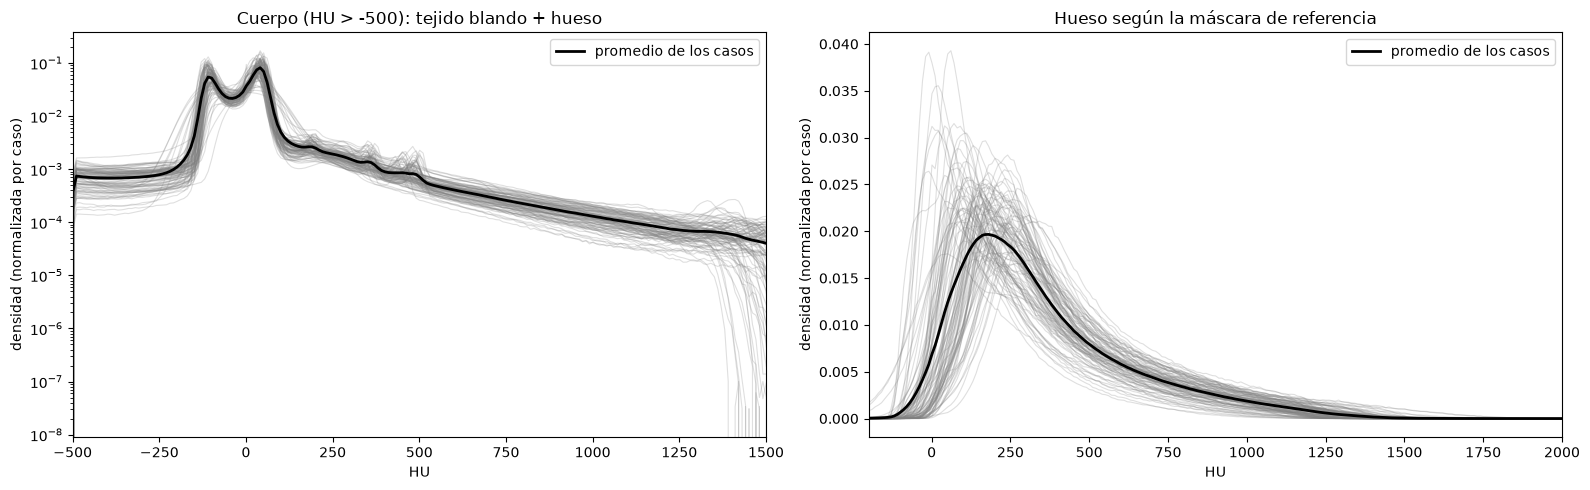

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, hist, titulo, xlim in [
    (axes[0], hist_cuerpo, "Cuerpo (HU > -500): tejido blando + hueso", (-500, 1500)),
    (axes[1], hist_hueso, "Hueso según la máscara de referencia", (-200, 2000)),
]:
    for h in hist:
        ax.plot(centers, h, color="gray", alpha=0.25, lw=0.8)
    ax.plot(centers, hist.mean(axis=0), color="black", lw=2, label="promedio de los casos")
    ax.set(title=titulo, xlabel="HU", ylabel="densidad (normalizada por caso)", xlim=xlim)
    ax.legend()
axes[0].set_yscale("log")
plt.tight_layout()
Path("outputs/eda").mkdir(parents=True, exist_ok=True)
plt.savefig("outputs/eda/intensidades_histogramas_superpuestos.png", dpi=150)
plt.show()

### 3.2 ¿Cuánto se mueve el hueso de un caso a otro?
Para cada caso: mediana de HU dentro de la máscara de hueso y banda p5–p95, ordenado por mediana. Una curva plana significaría que no hay desajuste.

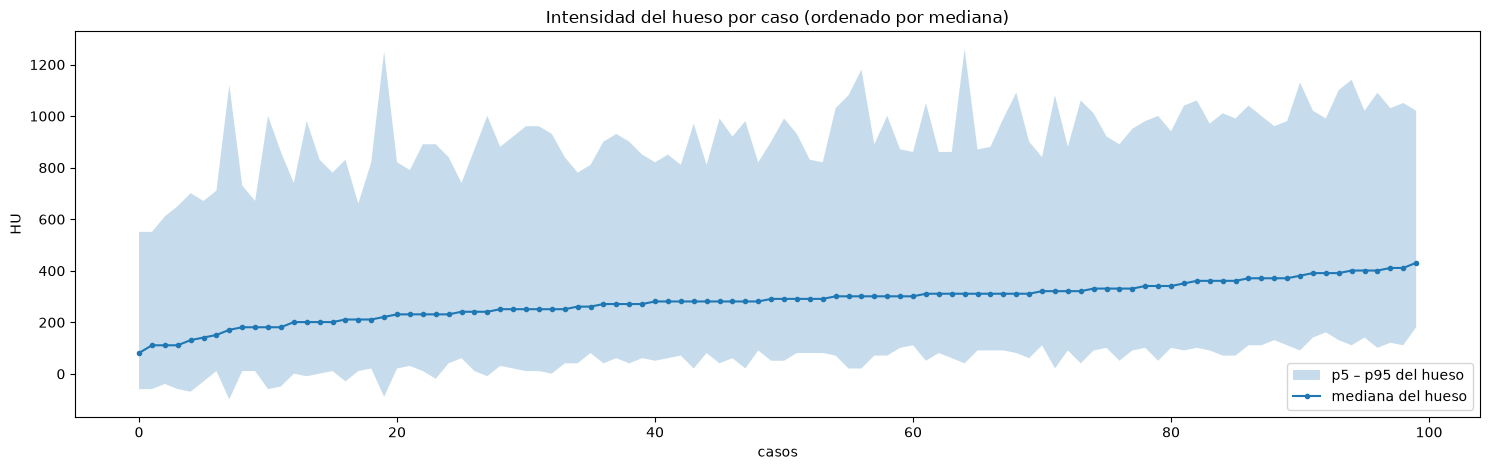

Mediana del hueso entre casos : min 81 | max 431 | media 282 | desv. 75 HU
Coeficiente de variación      : 26.5 %
Casos extremos (menor mediana): ['095', '034', '026'] | (mayor mediana): ['081', '003', '076']


In [5]:
d = df.sort_values("hueso_p50").reset_index(drop=True)
fig, ax = plt.subplots(figsize=(15, 4.8))
ax.fill_between(d.index, d["hueso_p5"], d["hueso_p95"], alpha=0.25, label="p5 – p95 del hueso")
ax.plot(d.index, d["hueso_p50"], "o-", ms=3, label="mediana del hueso")
ax.set(title="Intensidad del hueso por caso (ordenado por mediana)", xlabel="casos", ylabel="HU")
ax.legend(); plt.tight_layout()
plt.savefig("outputs/eda/intensidades_hueso_por_caso.png", dpi=150); plt.show()

print("Mediana del hueso entre casos : "
      f"min {d['hueso_p50'].min():.0f} | max {d['hueso_p50'].max():.0f} | "
      f"media {d['hueso_p50'].mean():.0f} | desv. {d['hueso_p50'].std():.0f} HU")
print(f"Coeficiente de variación      : {100 * d['hueso_p50'].std() / d['hueso_p50'].mean():.1f} %")
print("Casos extremos (menor mediana):", d['case_id'].head(3).tolist(), "| (mayor mediana):", d['case_id'].tail(3).tolist())

### 3.3 ¿Se explica por el escáner/protocolo?
No hay metadatos DICOM, pero hay dos huellas indirectas del equipo: el **valor de padding** (`hu_min`: -1023/-1024, -2048, otros) y el **spacing**. Si la intensidad del hueso cambia según estos grupos, el desajuste es sistemático (de adquisición) y no biológico.

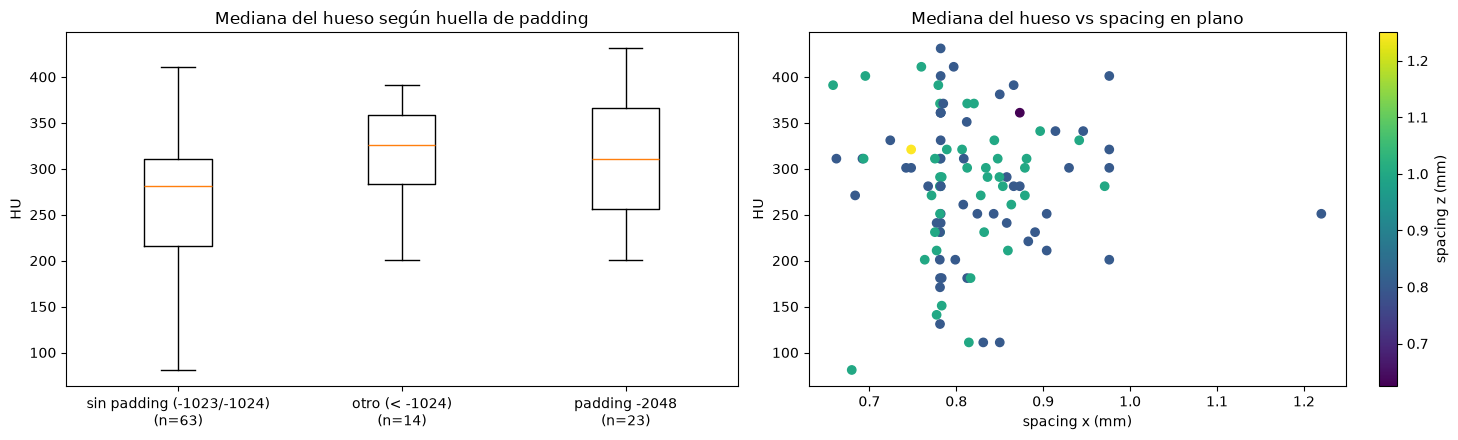

hueso_p50              hueso_std               \
                              count   mean   std     count   mean   std   
grupo_escaner                                                             
otro (< -1024)                   14  316.0  56.7        14  263.5  25.6   
padding -2048                    23  315.8  66.9        23  281.4  27.2   
sin padding (-1023/-1024)        63  262.0  74.6        63  263.1  43.5   

                          cuerpo_p50             
                               count mean   std  
grupo_escaner                                    
otro (< -1024)                    14 -8.3  29.5  
padding -2048                     23 -4.7  36.7  
sin padding (-1023/-1024)         63  2.7  28.4

In [6]:
m = df.merge(manifest[["case_id", "hu_min", "spacing_x_mm", "spacing_z_mm"]], on="case_id")

def grupo_padding(v):
    if v >= -1024: return "sin padding (-1023/-1024)"
    if v == -2048: return "padding -2048"
    return "otro (< -1024)"
m["grupo_escaner"] = m["hu_min"].apply(grupo_padding)

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
grupos = [g for g in m["grupo_escaner"].unique()]
axes[0].boxplot([m.loc[m["grupo_escaner"] == g, "hueso_p50"] for g in grupos])
axes[0].set_xticks(range(1, len(grupos) + 1))
axes[0].set_xticklabels([f"{g}\n(n={int((m['grupo_escaner'] == g).sum())})" for g in grupos])
axes[0].set(title="Mediana del hueso según huella de padding", ylabel="HU")
sc = axes[1].scatter(m["spacing_x_mm"], m["hueso_p50"], c=m["spacing_z_mm"], cmap="viridis")
plt.colorbar(sc, ax=axes[1], label="spacing z (mm)")
axes[1].set(title="Mediana del hueso vs spacing en plano", xlabel="spacing x (mm)", ylabel="HU")
plt.tight_layout(); plt.savefig("outputs/eda/intensidades_por_escaner.png", dpi=150); plt.show()

m.groupby("grupo_escaner")[["hueso_p50", "hueso_std", "cuerpo_p50"]].agg(["count", "mean", "std"]).round(1)

### 3.4 ¿Qué normalización reduce el desajuste?
Se comparan tres opciones usando una medida simple: **variación entre casos / variación dentro del caso** de la intensidad del hueso. Cuanto más baja, más se parece el hueso de un caso al de otro desde el punto de vista del modelo.

- **A. Ventana fija** (clip + C400/W1800): la actual. Es una transformación lineal idéntica para todos, así que no corrige el desajuste; sirve de línea base.
- **B. z-score por caso** con media y desviación del cuerpo (HU > -500).
- **C. Percentiles por caso**: reescalar entre p1 y p99 del cuerpo.

,variación entre casos / dentro del caso
A. ventana fija,0.278
B. z-score por caso (cuerpo),0.241
C. percentiles p1–p99 por caso,0.230


Menor es mejor. Mejor opción según esta medida: C. percentiles p1–p99 por caso


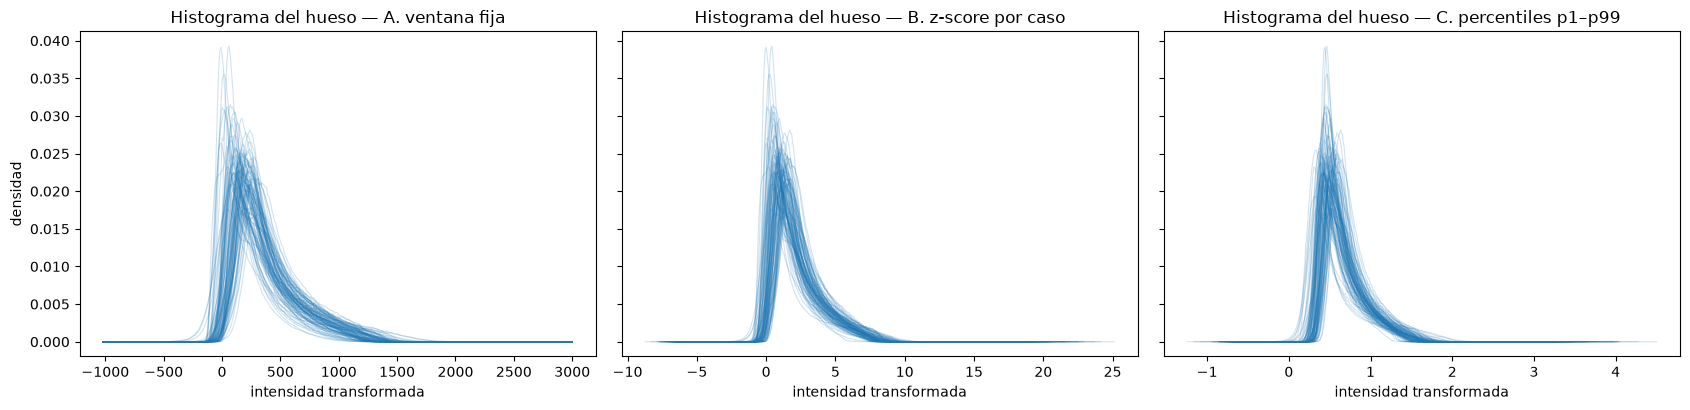

In [7]:
def razon_entre_dentro(mediana, dispersion):
    return float(np.std(mediana) / np.mean(dispersion))

res = {
    "A. ventana fija": razon_entre_dentro(df["hueso_p50"], df["hueso_std"]),
    "B. z-score por caso (cuerpo)": razon_entre_dentro((df["hueso_p50"] - df["cuerpo_media"]) / df["cuerpo_std"],
                                                        df["hueso_std"] / df["cuerpo_std"]),
    "C. percentiles p1–p99 por caso": razon_entre_dentro((df["hueso_p50"] - df["cuerpo_p1"]) / (df["cuerpo_p99"] - df["cuerpo_p1"]),
                                                          df["hueso_std"] / (df["cuerpo_p99"] - df["cuerpo_p1"])),
}
tabla = pd.DataFrame({"variación entre casos / dentro del caso": res}).round(3)
display(tabla)
print("Menor es mejor. Mejor opción según esta medida:", min(res, key=res.get))

fig, axes = plt.subplots(1, 3, figsize=(17, 4.2), sharey=True)
transformaciones = [
    ("A. ventana fija", lambda i: centers),
    ("B. z-score por caso", lambda i: (centers - df.loc[i, "cuerpo_media"]) / df.loc[i, "cuerpo_std"]),
    ("C. percentiles p1–p99", lambda i: (centers - df.loc[i, "cuerpo_p1"]) / (df.loc[i, "cuerpo_p99"] - df.loc[i, "cuerpo_p1"])),
]
for ax, (nombre, f) in zip(axes, transformaciones):
    for i in range(len(df)):
        ax.plot(f(i), hist_hueso[i], color="tab:blue", alpha=0.2, lw=0.8)
    ax.set(title=f"Histograma del hueso — {nombre}", xlabel="intensidad transformada")
axes[0].set_ylabel("densidad")
plt.tight_layout(); plt.savefig("outputs/eda/intensidades_comparacion_normalizacion.png", dpi=150); plt.show()

### Conclusión: desajuste de histograma

- **El desajuste existe y no es pequeño.** La mediana de HU del hueso (medida dentro de la máscara de referencia) va de **81 a 431 HU** entre casos (media 282, desviación 75 HU, **CV = 26.5 %**). Los extremos son los casos 095, 034 y 026 (hueso más "oscuro") y 081, 003 y 076 (más "brillante").
- **No es un problema de calibración de los escáneres.** En el histograma del cuerpo, los picos de grasa (≈ -100 HU) y de músculo (≈ +40 HU) caen en el mismo sitio en los 100 casos: la escala HU es consistente entre equipos. Lo que cambia de un caso a otro es sobre todo el **hueso**, lo que apunta a diferencias reales de densidad ósea entre pacientes (edad, osteoporosis) más que a la adquisición.
- **El equipo/protocolo explica poco.** Los casos sin padding (n=63) tienen hueso algo menos denso (262 HU) que los otros dos grupos (≈316 HU), pero las cajas se solapan casi por completo y la dispersión dentro de cada grupo (57–75 HU) es tan grande como la global: el grupo explica solo ~12 % de la varianza. Tampoco hay relación con el spacing.
- **Normalizar por caso ayuda poco.** Razón entre/dentro: ventana fija 0.278 → z-score 0.241 → percentiles p1–p99 0.230. La mejor opción reduce el desajuste apenas un 17 %, porque el tejido blando (que domina las estadísticas del cuerpo) ya estaba alineado.
- **Decisión:** se mantiene la **ventana fija** (clip [-1024, 3000] + C400/W1800), que conserva el significado físico de los HU y es idéntica en entrenamiento e inferencia. La variabilidad de densidad ósea entre pacientes se ataca con **aumento de datos de intensidad** (brillo/contraste/gamma aleatorios) en el entrenamiento. La normalización por percentiles queda como candidata para el estudio de ablación si sobra tiempo.
- **Implicación adicional:** con una mediana de 282 HU, cerca de la mitad de los vóxeles de hueso (el hueso trabecular) están por debajo de 250 HU. Un umbral de HU sirve para el MIP, donde domina la cortical, pero **no** como segmentación: justifica la necesidad del modelo.

## 4. Metal y endurecimiento de haz

### 4.1 ¿Cuántos casos tienen metal y cuánto?
Se marca un caso como "con metal" si tiene al menos `UMBRAL_METAL_MM3` de vóxeles > 3000 HU (un puñado de vóxeles sueltos puede ser ruido o hueso cortical muy denso, no un implante).

Casos con algún vóxel > 3000 HU          : 41 de 100
Casos con metal ≥ 100 mm³ (implante)   : 25 de 100
Casos con metal tocando la máscara de hueso: 1


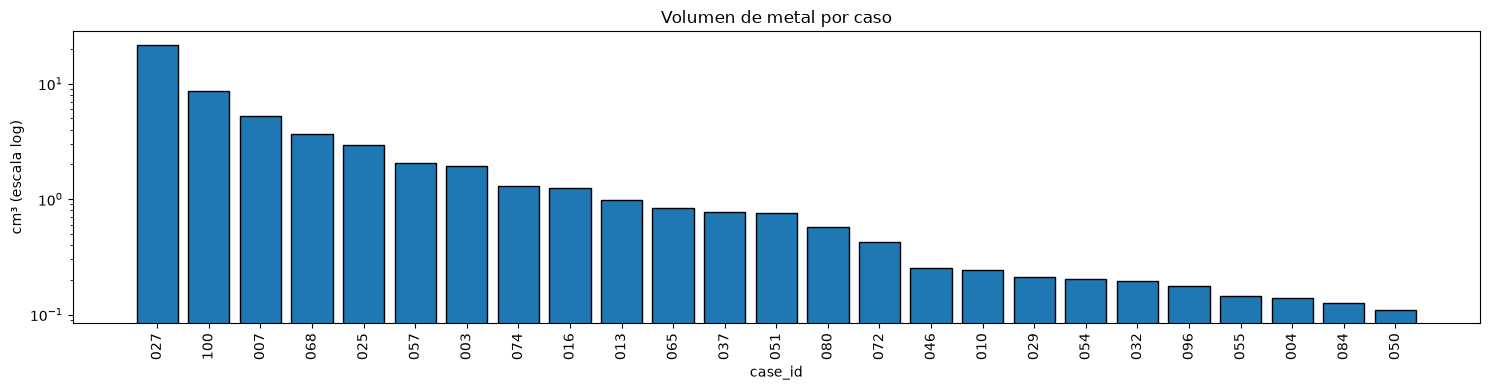

,case_id,hu_max_crudo,vol_metal_mm3,n_cortes_con_metal,corte_max_metal,metal_dentro_mascara_vox
26,027,10827.0,21810.121698,125,84,0
99,100,24970.0,8677.599643,199,127,0
6,007,19380.0,5278.671021,186,67,0
67,068,30445.0,3629.534782,109,323,0
24,025,12939.0,2946.387878,135,135,0
56,057,16749.0,2039.060501,105,60,0
2,003,16709.0,1929.148796,72,217,0
73,074,15467.0,1307.846412,43,231,0
15,016,3556.0,1251.220703,43,53,33
12,013,16941.0,987.792983,91,242,0


In [8]:
UMBRAL_METAL_MM3 = 100   # ajustable: volumen mínimo para considerar que hay un implante

df["con_metal"] = df["vol_metal_mm3"] >= UMBRAL_METAL_MM3
cm = df[df["con_metal"]].sort_values("vol_metal_mm3", ascending=False)
print(f"Casos con algún vóxel > 3000 HU          : {(df['n_vox_metal'] > 0).sum()} de {len(df)}")
print(f"Casos con metal ≥ {UMBRAL_METAL_MM3} mm³ (implante)   : {len(cm)} de {len(df)}")
print(f"Casos con metal tocando la máscara de hueso: {(df['metal_dentro_mascara_vox'] > 0).sum()}")

if len(cm):
    fig, ax = plt.subplots(figsize=(15, 4))
    ax.bar(cm["case_id"], cm["vol_metal_mm3"] / 1000, edgecolor="black")
    ax.set(title="Volumen de metal por caso", xlabel="case_id", ylabel="cm³ (escala log)", yscale="log")
    plt.xticks(rotation=90); plt.tight_layout()
    plt.savefig("outputs/eda/intensidades_metal_por_caso.png", dpi=150); plt.show()
cm[["case_id", "hu_max_crudo", "vol_metal_mm3", "n_cortes_con_metal", "corte_max_metal", "metal_dentro_mascara_vox"]].head(15)

In [9]:
# ¿En qué split cayeron los casos con metal? (si se concentran en uno solo, sesga la evaluación)
with open("data/splits.json") as f:
    sp = json.load(f)
mapa = {str(c).zfill(3): k for k in ("train", "val", "test") for c in sp[k]}
df["split"] = df["case_id"].map(mapa)
pd.crosstab(df["split"], df["con_metal"], margins=True)

con_metal,False,True,All
split,,,
test,12,3,15
train,51,19,70
val,12,3,15
All,75,25,100


### 4.2 Cómo se ve el endurecimiento de haz
Para los casos con más metal se muestra el corte con más vóxeles metálicos en **ventana de tejido blando** (C40/W400, donde las rayas se ven mejor) y en **ventana ósea** (la del modelo), con el metal resaltado en rojo y el contorno de la máscara de referencia en cian.

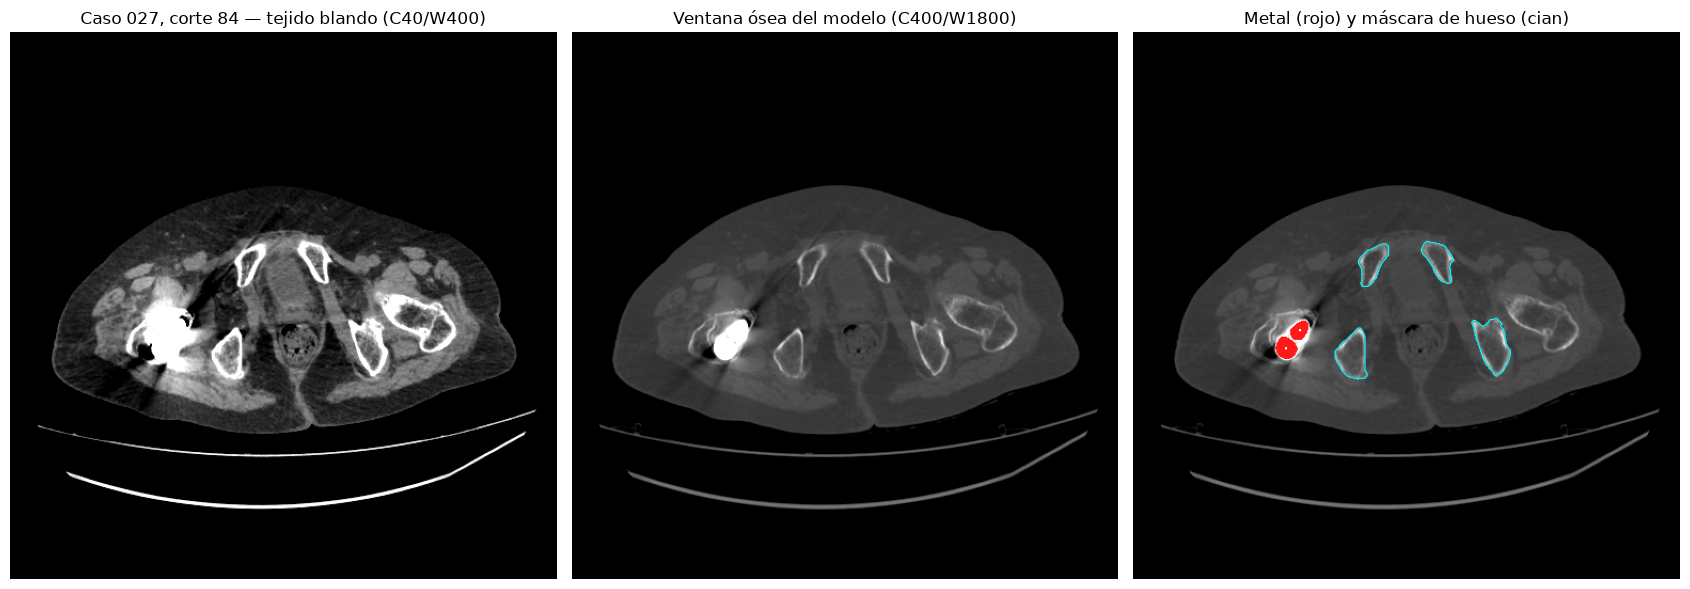

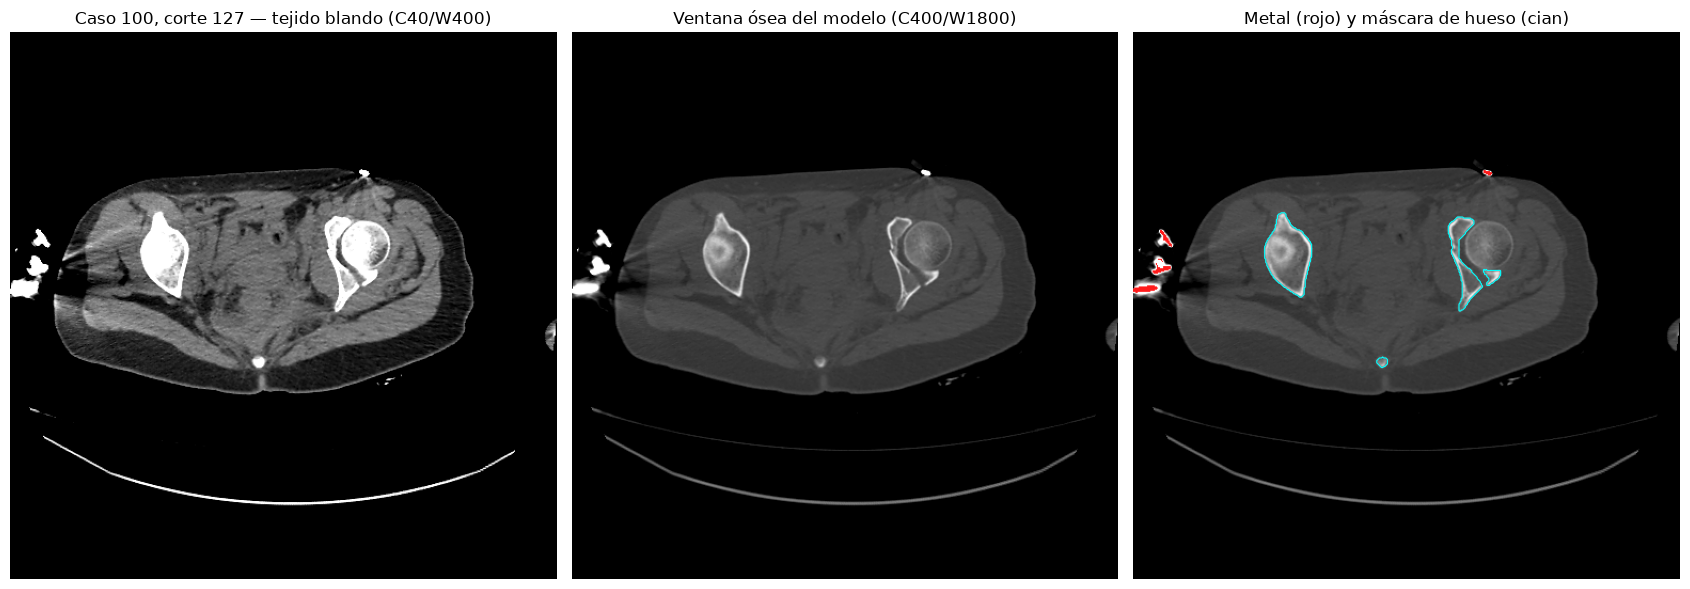

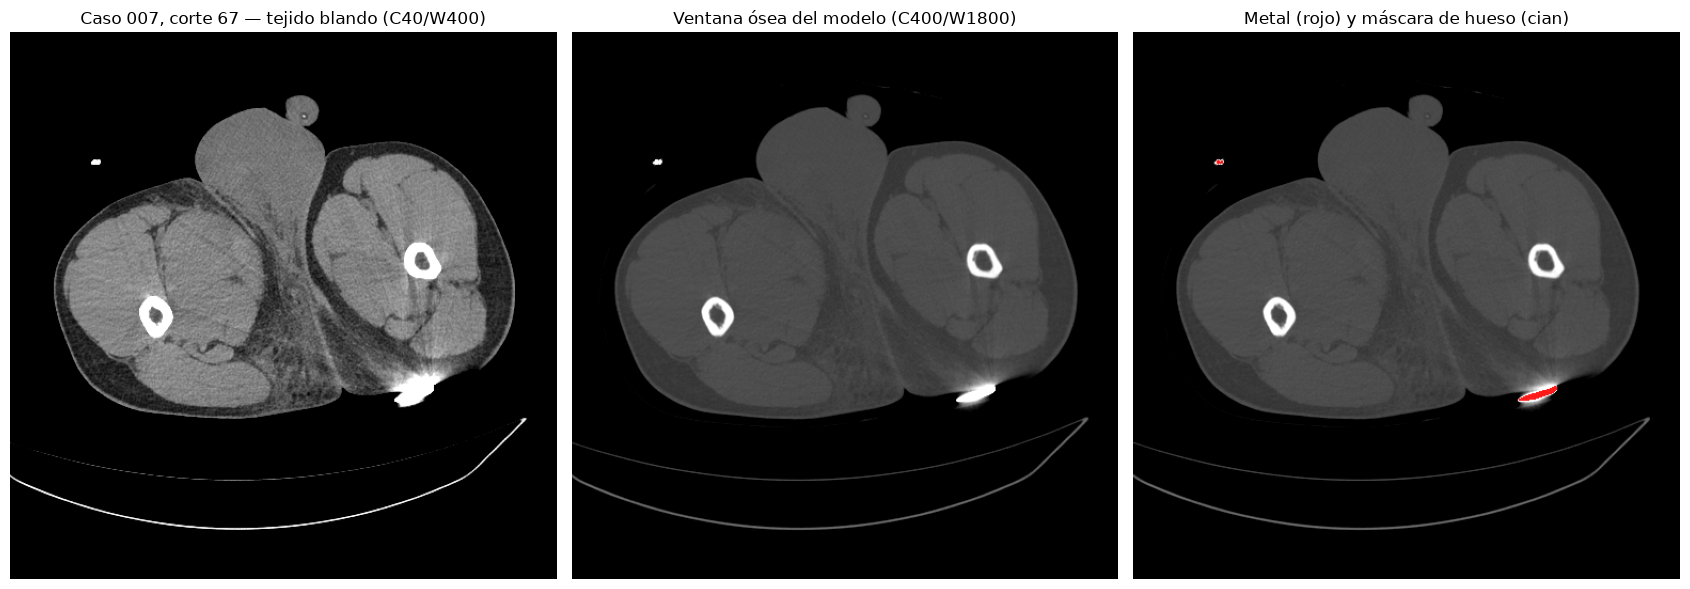

In [10]:
from matplotlib.colors import ListedColormap

def ventana(img, c, w):
    lo, hi = c - w / 2, c + w / 2
    return (np.clip(img, lo, hi) - lo) / (hi - lo)

top = cm["case_id"].head(3).tolist()
if not top:
    print("Ningún caso supera el umbral de metal.")
for cid in top:
    vol, lab, _ = eda_intensidades.load_case(cid)
    z = int(df.loc[df["case_id"] == cid, "corte_max_metal"].iloc[0])
    corte, mask = vol[z], lab[z]
    metal = np.ma.masked_where(corte <= eda_intensidades.HU_METAL, np.ones_like(corte))

    fig, axes = plt.subplots(1, 3, figsize=(17, 5.8))
    axes[0].imshow(ventana(corte, 40, 400), cmap="gray"); axes[0].set_title(f"Caso {cid}, corte {z} — tejido blando (C40/W400)")
    axes[1].imshow(ventana(np.clip(corte, -1024, 3000), 400, 1800), cmap="gray"); axes[1].set_title("Ventana ósea del modelo (C400/W1800)")
    axes[2].imshow(ventana(np.clip(corte, -1024, 3000), 400, 1800), cmap="gray")
    axes[2].imshow(metal, cmap=ListedColormap(["red"]), alpha=0.9)
    if mask.any():
        axes[2].contour(mask > 0, levels=[0.5], colors="cyan", linewidths=0.8)
    axes[2].set_title("Metal (rojo) y máscara de hueso (cian)")
    for a in axes: a.axis("off")
    plt.tight_layout(); plt.savefig(f"outputs/figures/beam_hardening_{cid}.png", dpi=150); plt.show()

### 4.3 ¿El metal altera los HU del hueso?
Comparación de la intensidad del hueso (ya excluyendo los vóxeles de metal) entre casos con y sin implante. Si el endurecimiento de haz contamina el hueso vecino, los casos con metal deberían mostrar mayor dispersión (`hueso_std`) o colas más largas (`hueso_p95`).

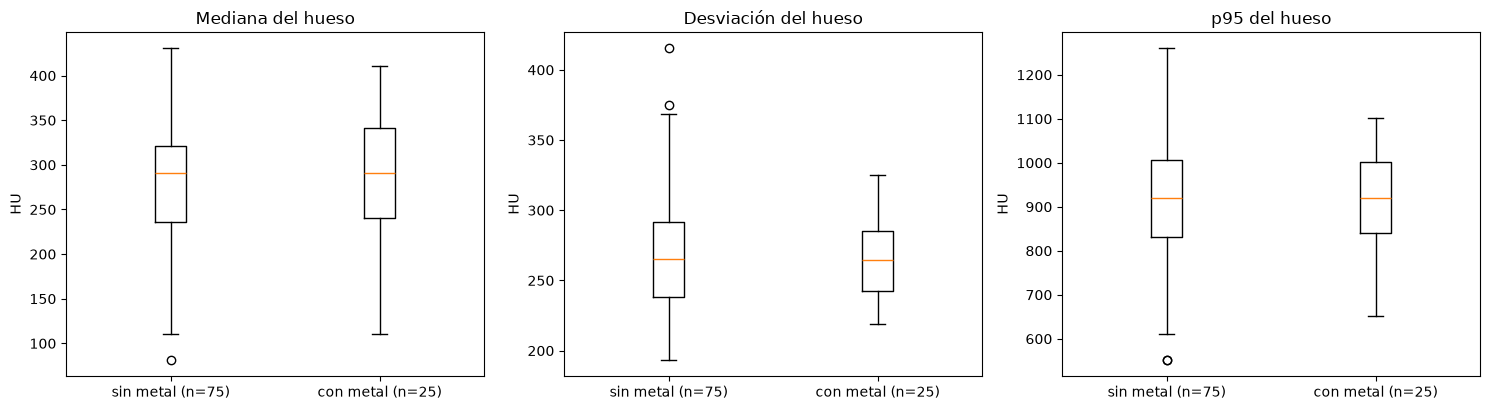

,hueso_p50,hueso_std,hueso_p95,cuerpo_std
con_metal,,,,
False,281.8,268.1,918.7,158.9
True,282.2,265.1,908.2,161.8


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, col, titulo in zip(axes, ["hueso_p50", "hueso_std", "hueso_p95"],
                           ["Mediana del hueso", "Desviación del hueso", "p95 del hueso"]):
    grupos = [df.loc[~df["con_metal"], col], df.loc[df["con_metal"], col]]
    etiquetas = [f"sin metal (n={len(grupos[0])})", f"con metal (n={len(grupos[1])})"]
    datos = [(g, e) for g, e in zip(grupos, etiquetas) if len(g)]
    ax.boxplot([g for g, _ in datos]); ax.set_xticks(range(1, len(datos) + 1)); ax.set_xticklabels([e for _, e in datos])
    ax.set(title=titulo, ylabel="HU")
plt.tight_layout(); plt.savefig("outputs/eda/intensidades_metal_vs_hueso.png", dpi=150); plt.show()

df.groupby("con_metal")[["hueso_p50", "hueso_std", "hueso_p95", "cuerpo_std"]].mean().round(1)

### Conclusión: metal y endurecimiento de haz

- **41 de 100** casos tienen algún vóxel > 3000 HU y **25 de 100** superan los 100 mm³ (objeto metálico real). El mayor es el caso 027 (21.8 cm³), seguido de 100, 007, 068 y 025.
- **Quedaron repartidos entre splits:** train 19/70 (27 %), val 3/15 (20 %), test 3/15 (20 %). La evaluación no queda sesgada hacia casos limpios ni hacia casos con metal.
- **El metal casi nunca está en el hueso pélvico:** solo 1 caso (016, 33 vóxeles) tiene metal dentro de la máscara. En las figuras se ve que proviene de **implantes femorales** (caso 027: prótesis/clavo en el fémur derecho) y de **objetos externos al paciente** (casos 100 y 007: fijadores u objetos sobre la camilla), no de osteosíntesis en la pelvis. Esto corrige la hipótesis inicial de "tornillos y placas pélvicas".
- **El endurecimiento de haz sí es visible:** en 027 y 100 hay bandas oscuras y brillantes que salen del metal y atraviesan el acetábulo y el ilion vecinos.
- **Pero su efecto es local, no global:** a nivel de caso completo, el hueso con metal y sin metal es indistinguible (mediana 282.2 vs 281.8 HU; desviación 265 vs 268; p95 908 vs 919). Las rayas afectan unos pocos cortes por caso y se diluyen en la estadística del volumen.
- **Decisión:** se mantiene el clip superior a 3000 HU (neutraliza el valor extremo; no elimina las rayas) y **no se excluye ningún caso**: los artefactos son parte del problema real y el modelo debe verlos en entrenamiento. Para el informe se reportarán las métricas **separadas con/sin metal** y se revisará si los cinco peores casos coinciden con cortes con rayas.
- **Limitación:** la comparación es por caso. Un análisis más fino compararía el hueso en cortes con metal frente a cortes sin metal del mismo paciente.

## 5. Padding
Fracción del volumen por debajo de -1024 HU (fuera del campo de reconstrucción). Se neutraliza con el clip, pero conviene saber cuánto del volumen es "vacío" para el muestreo de cortes.

In [12]:
print(f"Casos con padding (< -1024 HU): {(df['frac_padding'] > 0).sum()} de {len(df)}")
print(f"Fracción del volumen en padding: media {100 * df['frac_padding'].mean():.1f} % | máx {100 * df['frac_padding'].max():.1f} %")
df.sort_values("frac_padding", ascending=False)[["case_id", "hu_min_crudo", "frac_padding"]].head(8).round(3)

Casos con padding (< -1024 HU): 37 de 100
Fracción del volumen en padding: media 6.4 % | máx 33.0 %


,case_id,hu_min_crudo,frac_padding
10,011,-2285.0,0.330
68,069,-2048.0,0.319
89,090,-2048.0,0.310
9,010,-2048.0,0.301
93,094,-2048.0,0.299
73,074,-2913.0,0.293
41,042,-2048.0,0.239
99,100,-6152.0,0.221


## 6. Decisiones de preprocesamiento que salen de este EDA

| Hallazgo | Evidencia | Decisión |
|---|---|---|
| Padding por debajo del aire en 37 casos; ocupa en promedio 6.4 % del volumen y hasta 33 % (casos 011, 069, 090) | Sección 5 | `clip` inferior a -1024 HU. Al muestrear cortes para entrenar, tener en cuenta que parte del volumen es vacío |
| Metal > 3000 HU en 41 casos, 25 con más de 100 mm³; casi siempre fuera del hueso pélvico (implantes femorales y objetos externos) | 4.1, 4.2 | `clip` superior a 3000 HU. No se excluyen casos |
| Endurecimiento de haz visible cerca del metal (027, 100), sin efecto medible a nivel de caso (282.2 vs 281.8 HU) | 4.2, 4.3 | Se entrena con los artefactos. Métricas separadas con/sin metal en el informe |
| Casos con metal repartidos entre splits (27 % / 20 % / 20 %) | 4.1 | Se conservan los splits actuales |
| Densidad del hueso muy variable entre pacientes (mediana 81–431 HU, CV 26.5 %) con tejido blando alineado | 3.1, 3.2 | No es descalibración: es variabilidad biológica |
| El grupo de escáner explica ~12 % de esa varianza; normalizar por caso mejora solo 17 % | 3.3, 3.4 | Ventana fija C400/W1800 + aumento de datos de intensidad. Percentiles por caso queda como ablación opcional |
| ~Mitad del hueso (trabecular) está bajo 250 HU | 3.2 | El umbral HU se usa solo para el MIP, nunca como segmentación |

**Salidas generadas:** `src/eda_intensidades.py`, `data/eda_intensidades_detalle.csv`, `data/eda_intensidades_histogramas.npz`, `outputs/eda/intensidades_*.png`, `outputs/figures/beam_hardening_*.png`.